# EVA Large — Multi-View Pig Posture Recognition

Notebook przygotowany pod **Kaggle Notebook + GPU T4×2**.

Założenia pipeline'u:

- model: **EVA Large** z `timm`; preferowany checkpoint `eva02_large_patch14_224.mim_in22k`, bo jest natywnie zgodny z wejściem `224×224`,
- dane treningowe: wyłącznie `train2.csv` i `train2_images`, bez korekt etykiet,
- wejście: crop z bboxa, **padding = 0%**, resize do `224×224`,
- augmentacja: augmentacje per-kamera z `EficientNet_Augmentacja.ipynb`, razem z poprawnym swapem `Lateral_lying_left ↔ Lateral_lying_right` przy horizontal flip,
- loss: **Focal Loss bez alpha**,
- trening: jeden fold `StratifiedGroupKFold`, `group=image_id`,
- faza 1: zamrożony backbone, trenowana tylko ostatnia warstwa klasyfikacyjna, 6 epok, LR `1e-3`,
- faza 2: odmrożone ostatnie bloki transformera, domyślnie `8`, 8 epok, LR `1e-4`,
- inferencja: TTA `original + horizontal flip` z zamianą prawdopodobieństw klas 0/1,
- bezpieczeństwo: checkpoint `last` po każdej epoce, `best` przy poprawie walidacyjnego macro-F1, możliwość wznowienia.

**Ważne dla Kaggle:** w Settings ustaw `Accelerator = GPU T4 x2` oraz `Internet = ON`, bo `timm` pobiera wagi z Hugging Face Hub.


## Ważna uwaga o instalacji na Kaggle

Ta wersja notebooka celowo **nie** wykonuje `pip install --upgrade timm bitsandbytes` bez ograniczeń zależności. W środowisku Kaggle takie polecenie może nadpisać pakiety binarne powiązane z PyTorch i doprowadzić do błędu importu `torch`. Komórka instalacyjna najpierw importuje preinstalowany `torch`, a potem instaluje/aktualizuje wyłącznie `timm` i opcjonalnie `bitsandbytes` z flagą `--no-deps`.

Jeżeli uruchomiono wcześniejszą wersję komórki i `import torch` już się wysypuje, trzeba zrestartować kernel/session przed ponownym uruchomieniem notebooka.


In [1]:
# Bezpieczna instalacja zależności dla Kaggle.
# WAŻNE: nie używamy `pip install --upgrade timm bitsandbytes` bez --no-deps,
# bo pip może nadpisać torch/torchvision w preinstalowanym środowisku Kaggle.
# Jeżeli wcześniej uruchomiłeś starą komórkę i import torch już się wysypuje,
# zrestartuj kernel/session i uruchom notebook od tej wersji komórki.

import os, ast, re, time, math, gc, random, json, warnings, sys, subprocess, importlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

# Najpierw importujemy preinstalowane torch/torchvision z Kaggle, żeby upewnić się,
# że bazowe środowisko działa. Potem ewentualnie instalujemy tylko brakujące paczki.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF


def safe_pip_install(*packages):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', '--no-input', '--no-deps', '--upgrade', *packages]
    print('Running:', ' '.join(cmd))
    subprocess.check_call(cmd)

# timm jest wymagany do EVA Large. Instalujemy/aktualizujemy bez zależności,
# żeby nie naruszyć wersji torch/torchvision z obrazu Kaggle.
try:
    import timm
except Exception:
    safe_pip_install('timm')
    import timm

# Jeżeli stara wersja timm nie zawiera EVA Large, aktualizujemy tylko timm, nadal bez zależności.
if len(timm.list_models('*eva*large*224*')) == 0:
    safe_pip_install('timm')
    importlib.reload(timm)

# bitsandbytes jest opcjonalny. Jeżeli import/instalacja zawiedzie, notebook przejdzie na torch.optim.AdamW.
try:
    import bitsandbytes as bnb
except Exception as e:
    print(f'bitsandbytes initially unavailable: {repr(e)}')
    try:
        safe_pip_install('bitsandbytes')
        import bitsandbytes as bnb
    except Exception as e2:
        bnb = None
        print(f'bitsandbytes disabled, fallback to torch AdamW: {repr(e2)}')

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

print(f'python: {sys.version.split()[0]}')
print(f'torch:  {torch.__version__}')
print(f'cuda:   {torch.version.cuda}')
print(f'timm:   {timm.__version__}')
if bnb is not None:
    print(f'bitsandbytes: {bnb.__version__}')
else:
    print('bitsandbytes: unavailable; using torch AdamW')


bitsandbytes initially unavailable: ModuleNotFoundError("No module named 'bitsandbytes'")
Running: /usr/bin/python3 -m pip install -q --no-input --no-deps --upgrade bitsandbytes
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00
python: 3.12.12
torch:  2.10.0+cu128
cuda:   12.8
timm:   1.0.25
bitsandbytes: 0.49.2


In [2]:
# ── Konfiguracja globalna ─────────────────────────────────────────────────────
SEED = 42

CLASS_NAMES = {
    0: 'Lateral_lying_left',
    1: 'Lateral_lying_right',
    2: 'Sitting',
    3: 'Standing',
    4: 'Sternal_lying',
}
NUM_CLASSES = len(CLASS_NAMES)

# Jeden fold zamiast pełnego 5-fold CV.
N_SPLITS = 5
FOLD_ID = 0

# EVA Large. Preferujemy model natywnie działający na 224×224.
# `eva02_large_patch14_224.mim_in22k` to feature/representation model, więc używamy go jako backbone z własną głową 5-klasową.
PREFERRED_MODEL_NAME = 'eva02_large_patch14_224.mim_in22k'
EVA_LARGE_CANDIDATES = [
    'eva02_large_patch14_224.mim_in22k',
    'eva02_large_patch14_224.mim_m38m',
    'eva02_large_patch14_clip_224.merged2b_s4b_b131k',
    'eva02_large_patch14_clip_224.merged2b',
]

IMG_SIZE = 224
PADDING = 0.0

# EVA Large ma około 303–304M parametrów, więc jest dużo lżejsza od EVA Giant.
# Batch size jest nadal konserwatywny pod T4×2. Jeżeli pojawi się OOM w fazie 2,
# zmniejsz BATCH_SIZE_P2 do 6 albo 4.
BATCH_SIZE_P1 = 32     # backbone frozen; forward bez gradientów przez backbone
BATCH_SIZE_P2 = 8      # DataParallel dzieli globalny batch na 2 GPU, czyli ~4 obrazki/GPU
EVAL_BATCH_SIZE = 32

# Gradient accumulation utrzymuje większy effective batch bez zwiększania pamięci.
ACCUM_STEPS_P1 = 1
ACCUM_STEPS_P2 = 4

# Ustawienia epok zgodnie z pierwotnym planem.
EPOCHS_P1 = 6
LR_P1 = 1e-3
EPOCHS_P2 = 7
LR_P2 = 1e-4

# Dla EVA Large nie odmrażamy 32 bloków: model ma zwykle 24 bloki, więc 32 oznaczałoby cały backbone.
# Domyślnie odmrażamy ostatnie 8 bloków, czyli agresywny, ale rozsądny fine-tuning końcówki.
UNFREEZE_LAST_N_BLOCKS = 16

# Focal Loss bez alpha.
FOCAL_GAMMA = 1.5

# Capping kroków na epokę zabezpiecza limit 12h Kaggle.
# None = pełna epoka po całym samplerze.
MAX_STEPS_PER_EPOCH_P1 = None
MAX_STEPS_PER_EPOCH_P2 = None

# Limit czasu sesji Kaggle. Notebook zapisuje checkpoint i kończy fazę, gdy zbliża się limit.
TIME_BUDGET_HOURS = 11.5
SAFETY_MARGIN_MINUTES = 20

USE_AMP = True
USE_8BIT_OPTIMIZER = True
USE_GRADIENT_CHECKPOINTING = True
USE_DATA_PARALLEL = True

NUM_WORKERS = 2
WEIGHT_DECAY = 1e-4
CLASSIFIER_DROPOUT = 0.20

# Checkpointy. Trzymamy last i best jako nadpisywane pliki, żeby nie zapełnić /kaggle/working.
OUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
CKPT_LAST = OUT_DIR / 'eva_large_last_checkpoint.pt'
CKPT_BEST = OUT_DIR / 'eva_large_best_checkpoint.pt'
CKPT_PHASE1 = OUT_DIR / 'eva_large_phase1_final.pt'
CKPT_PHASE2 = OUT_DIR / 'eva_large_phase2_final.pt'
SUBMISSION_PATH = OUT_DIR / 'submission_eva_large_tta.csv'
HISTORY_PATH = OUT_DIR / 'eva_large_history.csv'

RESUME_IF_AVAILABLE = True

print('Config ready')
print(f'Output dir: {OUT_DIR}')
print(f'IMG_SIZE={IMG_SIZE}, PADDING={PADDING}')
print(f'Model preference: {PREFERRED_MODEL_NAME}')
print(f'Phase 1: {EPOCHS_P1} epochs, lr={LR_P1}, batch={BATCH_SIZE_P1}, accum={ACCUM_STEPS_P1}, max_steps={MAX_STEPS_PER_EPOCH_P1}')
print(f'Phase 2: {EPOCHS_P2} epochs, lr={LR_P2}, batch={BATCH_SIZE_P2}, accum={ACCUM_STEPS_P2}, max_steps={MAX_STEPS_PER_EPOCH_P2}, unfreeze_last_blocks={UNFREEZE_LAST_N_BLOCKS}')


Config ready
Output dir: /kaggle/working
IMG_SIZE=224, PADDING=0.0
Model preference: eva02_large_patch14_224.mim_in22k
Phase 1: 6 epochs, lr=0.001, batch=32, accum=1, max_steps=None
Phase 2: 7 epochs, lr=0.0001, batch=8, accum=4, max_steps=None, unfreeze_last_blocks=16


In [3]:
# ── Reproducibility i GPU ─────────────────────────────────────────────────────
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if DEVICE.type == 'cuda' else 0
USE_DP = bool(USE_DATA_PARALLEL and NUM_GPUS >= 2)

if DEVICE.type == 'cuda':
    AMP_DTYPE = torch.float16  # T4 nie wspiera bf16; fp16 jest właściwym wyborem.
else:
    AMP_DTYPE = torch.float32

print(f'Device: {DEVICE}')
print(f'GPU count: {NUM_GPUS}')
for i in range(NUM_GPUS):
    print(f'  [{i}] {torch.cuda.get_device_name(i)}')
print(f'DataParallel: {USE_DP}')
print(f'AMP dtype: {AMP_DTYPE}')


Device: cuda
GPU count: 2
  [0] Tesla T4
  [1] Tesla T4
DataParallel: True
AMP dtype: torch.float16


In [4]:
# ── Lokalizacja danych Kaggle ─────────────────────────────────────────────────
def find_base_dir():
    candidates = [
        Path('/kaggle/input/competitions/multi-view-pig-posture-recognition/multiview_pig_posture_recognition'),
        Path('/kaggle/input/multi-view-pig-posture-recognition/multiview_pig_posture_recognition'),
        Path('/kaggle/input/multiview-pig-posture-recognition/multiview_pig_posture_recognition'),
        Path('/kaggle/input/multi-view-pig-posture-recognition'),
        Path('/kaggle/input/multiview-pig-posture-recognition'),
        Path('multiview_pig_posture_recognition'),
        Path('.'),
    ]
    for p in candidates:
        if (p / 'train2.csv').exists() and (p / 'test.csv').exists():
            return p

    root = Path('/kaggle/input')
    if root.exists():
        hits = list(root.rglob('train2.csv'))
        for h in hits:
            p = h.parent
            if (p / 'test.csv').exists():
                return p
    raise FileNotFoundError('Nie znaleziono train2.csv/test.csv. Dodaj dane konkursu w Kaggle: + Add Input.')

BASE_DIR = find_base_dir()
TRAIN2_IMGS = BASE_DIR / 'train2_images'
TEST_IMGS = BASE_DIR / 'test_images'

assert TRAIN2_IMGS.exists(), f'Brak folderu: {TRAIN2_IMGS}'
assert TEST_IMGS.exists(), f'Brak folderu: {TEST_IMGS}'

print(f'BASE_DIR: {BASE_DIR}')
print(f'TRAIN2_IMGS: {TRAIN2_IMGS}')
print(f'TEST_IMGS:   {TEST_IMGS}')


BASE_DIR: /kaggle/input/competitions/multi-view-pig-posture-recognition/multiview_pig_posture_recognition
TRAIN2_IMGS: /kaggle/input/competitions/multi-view-pig-posture-recognition/multiview_pig_posture_recognition/train2_images
TEST_IMGS:   /kaggle/input/competitions/multi-view-pig-posture-recognition/multiview_pig_posture_recognition/test_images


In [5]:
# ── Wczytanie train2/test; bez korekty etykiet ────────────────────────────────
def parse_camera_meta(image_id):
    m = re.match(r'(pen\d+)_(orb|tur)_(cam\d+)_', str(image_id))
    return (m.group(1), m.group(2), m.group(3)) if m else ('unknown', 'unknown', 'unknown')

def add_camera_cols(df):
    df = df.copy()
    meta = df['image_id'].apply(parse_camera_meta)
    df['pen'] = meta.apply(lambda x: x[0])
    df['cam_type'] = meta.apply(lambda x: x[1])
    df['cam_num'] = meta.apply(lambda x: x[2])
    df['camera'] = df['pen'] + '_' + df['cam_type'] + '_' + df['cam_num']
    return df

train2 = pd.read_csv(BASE_DIR / 'train2.csv')
train2['source'] = 'train2'
train2['bbox_parsed'] = train2['bbox'].apply(ast.literal_eval)
train2['class_name'] = train2['class_id'].map(CLASS_NAMES)
train2 = add_camera_cols(train2)

test = pd.read_csv(BASE_DIR / 'test.csv')
test['source'] = 'test'
test['bbox_parsed'] = test['bbox'].apply(ast.literal_eval)
test = add_camera_cols(test)

print(f'Train2: {len(train2):,} bboxów | {train2.image_id.nunique():,} zdjęć')
print(f'Test:   {len(test):,} bboxów | {test.image_id.nunique():,} zdjęć')
print('\nRozkład klas train2:')
print(train2['class_name'].value_counts().to_string())
print('\nKamery train2:')
print(train2.groupby('camera').size().sort_values(ascending=False).to_string())


Train2: 23,450 bboxów | 3,150 zdjęć
Test:   11,708 bboxów | 1,350 zdjęć

Rozkład klas train2:
class_name
Standing               9928
Sternal_lying          6309
Lateral_lying_right    3435
Lateral_lying_left     3083
Sitting                 695

Kamery train2:
camera
pen2_tur_cam1    9713
pen1_tur_cam2    8194
pen2_orb_cam1    2817
pen1_orb_cam2    1488
pen1_orb_cam1     722
pen1_tur_cam1     200
pen2_tur_cam2     196
pen2_orb_cam2     120


In [6]:
# ── Jeden fold: StratifiedGroupKFold po image_id ──────────────────────────────
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(sgkf.split(train2, y=train2['class_id'], groups=train2['image_id']))
train_idx, val_idx = folds[FOLD_ID]

tr_df = train2.iloc[train_idx].reset_index(drop=True)
val_df = train2.iloc[val_idx].reset_index(drop=True)

print(f'Fold {FOLD_ID}/{N_SPLITS-1}')
print(f'Train fold: {len(tr_df):,} bboxów | {tr_df.image_id.nunique():,} zdjęć')
print(f'Val fold:   {len(val_df):,} bboxów | {val_df.image_id.nunique():,} zdjęć')
print('\nTrain class distribution:')
print(tr_df['class_name'].value_counts(normalize=True).sort_index().to_string())
print('\nVal class distribution:')
print(val_df['class_name'].value_counts(normalize=True).sort_index().to_string())


Fold 0/4
Train fold: 18,766 bboxów | 2,518 zdjęć
Val fold:   4,684 bboxów | 632 zdjęć

Train class distribution:
class_name
Lateral_lying_left     0.131568
Lateral_lying_right    0.146648
Sitting                0.030694
Standing               0.422946
Sternal_lying          0.268145

Val class distribution:
class_name
Lateral_lying_left     0.131085
Lateral_lying_right    0.145816
Sitting                0.025406
Standing               0.425064
Sternal_lying          0.272630


In [7]:
# ── Crop bez paddingu + augmentacje per kamera z EficientNet_Augmentacja.ipynb ─
def load_image(image_id, source):
    folder = {'train2': TRAIN2_IMGS, 'test': TEST_IMGS}[source]
    return Image.open(folder / image_id).convert('RGB')

def crop_bbox_no_padding(image, bbox):
    """bbox = [x_top_left, y_top_left, width, height]. Padding = 0%, bez make_square."""
    img_w, img_h = image.size
    x, y, w, h = map(float, bbox)
    x1 = max(0, int(round(x)))
    y1 = max(0, int(round(y)))
    x2 = min(img_w, int(round(x + w)))
    y2 = min(img_h, int(round(y + h)))
    return image.crop((x1, y1, max(x2, x1 + 1), max(y2, y1 + 1)))

# Label swap dla horizontal flip.
FLIP_LABEL_MAP = {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}
PROB_FLIP_INDEX = torch.tensor([1, 0, 2, 3, 4], dtype=torch.long)

def aug_pen2_tur_cam1(img):
    img = TF.hflip(img)
    img = TF.adjust_saturation(img, saturation_factor=0.8)
    img = TF.adjust_brightness(img, brightness_factor=0.95)
    return img

def aug_pen1_tur_cam2(img):
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=1.35)
    img = TF.adjust_saturation(img, saturation_factor=0.9)
    return img

def aug_pen2_orb_cam1(img):
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=0.6)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_np = np.array(img).astype(float)
    img_np[:, :, 0] = (img_np[:, :, 0] * 0.85).clip(0, 255)
    img_np[:, :, 1] = (img_np[:, :, 1] * 1.10).clip(0, 255)
    img_np[:, :, 2] = (img_np[:, :, 2] * 0.80).clip(0, 255)
    img_shifted = Image.fromarray(img_np.clip(0, 255).astype(np.uint8))
    img_grey = TF.to_grayscale(img_shifted, num_output_channels=3)
    grey_np = np.array(img_grey).astype(float)
    blended = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

def aug_pen2_tur_cam2(img):
    img = TF.adjust_brightness(img, brightness_factor=1.3)
    img = TF.adjust_saturation(img, saturation_factor=0.85)
    return img

def aug_pen2_orb_cam2(img):
    img = TF.adjust_brightness(img, brightness_factor=0.60)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_grey = TF.to_grayscale(img, num_output_channels=3)
    img_np = np.array(img).astype(float)
    grey_np = np.array(img_grey).astype(float)
    blended = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

CAMERA_AUG_FN = {
    'pen2_tur_cam1': (aug_pen2_tur_cam1, True),
    'pen1_tur_cam2': (aug_pen1_tur_cam2, True),
    'pen2_orb_cam1': (aug_pen2_orb_cam1, True),
    'pen2_tur_cam2': (aug_pen2_tur_cam2, False),
    'pen2_orb_cam2': (aug_pen2_orb_cam2, False),
}

print('Camera augmentations:')
for cam, (_, flip) in CAMERA_AUG_FN.items():
    print(f'  {cam:20s} flip_label={flip}')


Camera augmentations:
  pen2_tur_cam1        flip_label=True
  pen1_tur_cam2        flip_label=True
  pen2_orb_cam1        flip_label=True
  pen2_tur_cam2        flip_label=False
  pen2_orb_cam2        flip_label=False


In [8]:
# ── Transformacje ─────────────────────────────────────────────────────────────
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.15):
        self.std = std
        self.p = p
    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            tensor = torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)
        return tensor

# Dla EVA-CLIP w timm zwykle ImageNet mean/std; zostawiamy zgodnie z poprzednim pipeline'em.
MU = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.15),
    transforms.Normalize(MU, STD),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MU, STD),
])

class PigDatasetCameraAug(Dataset):
    """Train dataset: oryginał + augmentacja per kamera, z poprawnym label swap przy flipie."""
    def __init__(self, df, transform, camera_aug_fn=None, is_train=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.camera_aug_fn = camera_aug_fn or {}
        self.is_train = is_train
        self.samples = []
        for row_idx, row in self.df.iterrows():
            label = int(row['class_id'])
            self.samples.append((row_idx, False, label))
            cam = row.get('camera', 'unknown')
            if is_train and cam in self.camera_aug_fn:
                _, does_flip = self.camera_aug_fn[cam]
                aug_label = FLIP_LABEL_MAP[label] if does_flip else label
                self.samples.append((row_idx, True, aug_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row_idx, do_aug, label = self.samples[idx]
        row = self.df.iloc[row_idx]
        img = load_image(row['image_id'], row['source'])
        crop = crop_bbox_no_padding(img, row['bbox_parsed'])
        if do_aug:
            aug_fn, _ = self.camera_aug_fn[row['camera']]
            crop = aug_fn(crop)
        x = self.transform(crop)
        return x, int(label)

class PigEvalDataset(Dataset):
    def __init__(self, df, transform, source='train2', tta_mode='orig', return_label=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.source = source
        self.tta_mode = tta_mode
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_image(row['image_id'], row['source'])
        crop = crop_bbox_no_padding(img, row['bbox_parsed'])
        if self.tta_mode == 'hflip':
            crop = TF.hflip(crop)
        x = self.transform(crop)
        row_id = str(row.get('row_id', idx))
        if self.return_label:
            return x, int(row['class_id']), row_id
        return x, row_id

train_ds = PigDatasetCameraAug(tr_df, TRAIN_TRANSFORM, CAMERA_AUG_FN, is_train=True)
val_ds = PigEvalDataset(val_df, VAL_TRANSFORM, return_label=True)

train_labels = np.array([s[2] for s in train_ds.samples], dtype=int)
counts_aug = np.bincount(train_labels, minlength=NUM_CLASSES)
print(f'Train samples after camera augmentation: {len(train_ds):,}')
print(f'Val samples: {len(val_ds):,}')
print('\nClass distribution after augmentation:')
for cid, cnt in enumerate(counts_aug):
    print(f'  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:>6,}')


Train samples after camera augmentation: 35,627
Val samples: 4,684

Class distribution after augmentation:
  [0] Lateral_lying_left       :  5,029
  [1] Lateral_lying_right      :  4,853
  [2] Sitting                  :  1,128
  [3] Standing                 : 15,320
  [4] Sternal_lying            :  9,297


In [9]:
# ── Loadery z ważonym samplerem ───────────────────────────────────────────────
def make_train_loader(dataset, labels, batch_size, max_steps_per_epoch=None, num_workers=NUM_WORKERS):
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    class_inv = 1.0 / np.maximum(counts, 1)
    sample_weights = class_inv[labels]

    if max_steps_per_epoch is None:
        num_samples = len(dataset)
    else:
        num_samples = int(max_steps_per_epoch * batch_size)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=num_samples,
        replacement=True,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        drop_last=True,
    )

def make_eval_loader(dataset, batch_size=EVAL_BATCH_SIZE, num_workers=NUM_WORKERS):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        drop_last=False,
    )

train_loader_p1 = make_train_loader(train_ds, train_labels, BATCH_SIZE_P1, MAX_STEPS_PER_EPOCH_P1)
train_loader_p2 = make_train_loader(train_ds, train_labels, BATCH_SIZE_P2, MAX_STEPS_PER_EPOCH_P2)
val_loader = make_eval_loader(val_ds)

print(f'P1 train batches: {len(train_loader_p1):,}')
print(f'P2 train batches: {len(train_loader_p2):,}')
print(f'Val batches:      {len(val_loader):,}')


P1 train batches: 1,113
P2 train batches: 4,453
Val batches:      147


In [10]:
# ── Wybór checkpointu EVA Large z timm ────────────────────────────────────────
available_eva_large = sorted(set(timm.list_models('*eva*large*') + timm.list_models('*eva02*large*')))
available_eva_large_224 = [m for m in available_eva_large if '_224' in m or 'patch14_224' in m]

print('Dostępne modele timm pasujące do *eva*large* / *eva02*large*:')
for m in available_eva_large:
    print('  ', m)

print('\nModele 224×224:')
for m in available_eva_large_224:
    print('  ', m)

MODEL_NAME = 'eva02_large_patch14_224.mim_in22k'
if PREFERRED_MODEL_NAME in available_eva_large:
    MODEL_NAME = PREFERRED_MODEL_NAME
else:
    for cand in EVA_LARGE_CANDIDATES:
        if cand in available_eva_large:
            MODEL_NAME = cand
            break

if MODEL_NAME is None:
    raise ValueError(
        'Nie znaleziono EVA Large 224 w aktualnej wersji timm. '
        'Sprawdź listę powyżej, włącz Internet=ON albo ustaw ręcznie MODEL_NAME na dostępny wariant.'
    )

if '224' not in MODEL_NAME:
    print(f'UWAGA: wybrany model {MODEL_NAME} może nie być natywnie 224×224. Sprawdź IMG_SIZE przed treningiem.')

print(f'\nWybrany model: {MODEL_NAME}')


Dostępne modele timm pasujące do *eva*large* / *eva02*large*:
   eva02_large_patch14_224
   eva02_large_patch14_448
   eva02_large_patch14_clip_224
   eva02_large_patch14_clip_336
   eva_large_patch14_196
   eva_large_patch14_336

Modele 224×224:
   eva02_large_patch14_224
   eva02_large_patch14_clip_224

Wybrany model: eva02_large_patch14_224.mim_in22k


In [11]:
# ── Model: EVA Large backbone + pojedyncza finalna warstwa klasyfikacyjna ─────
class EvaLargeClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.2):
        super().__init__()
        # num_classes=0 usuwa oryginalny head timm i zwraca embedding obrazu.
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        self.num_features = int(getattr(self.backbone, 'num_features'))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.num_features, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        # W większości modeli num_classes=0 zwraca [B, C]. Gdyby zwrócił tokeny [B, N, C], bierzemy token CLS/średnią.
        if feats.ndim == 3:
            feats = feats[:, 0]
        return self.head(self.dropout(feats))

def bare(model):
    return model.module if hasattr(model, 'module') else model

def get_transformer_blocks(model):
    m = bare(model)
    candidates = [
        getattr(m.backbone, 'blocks', None),
        getattr(m.backbone, 'layers', None),
        getattr(m.backbone, 'stages', None),
    ]
    for blocks in candidates:
        if blocks is not None and hasattr(blocks, '__len__') and len(blocks) > 0:
            return blocks
    raise AttributeError('Nie mogę znaleźć listy bloków transformera w backbone. Sprawdź strukturę modelu.')

def set_gradient_checkpointing(model, enabled=True):
    m = bare(model)
    if hasattr(m.backbone, 'set_grad_checkpointing'):
        m.backbone.set_grad_checkpointing(enabled)
        print(f'Gradient checkpointing: {enabled}')
    elif hasattr(m.backbone, 'grad_checkpointing'):
        m.backbone.grad_checkpointing = enabled
        print(f'Gradient checkpointing flag set: {enabled}')
    else:
        print('Gradient checkpointing not exposed by this timm model.')

def freeze_backbone_train_head_only(model):
    m = bare(model)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.head.parameters():
        p.requires_grad = True
    # Dropout nie ma parametrów; faza 1 trenuje tylko finalny Linear.

def unfreeze_last_n_blocks(model, n=8):
    m = bare(model)
    for p in m.parameters():
        p.requires_grad = False

    # Head zawsze uczymy.
    for p in m.head.parameters():
        p.requires_grad = True

    blocks = get_transformer_blocks(model)
    total = len(blocks)
    n = min(n, total)
    for block in blocks[total - n:]:
        for p in block.parameters():
            p.requires_grad = True

    # Końcowe normy warto odmrozić razem z końcówką transformera.
    for attr in ['norm', 'fc_norm']:
        layer = getattr(m.backbone, attr, None)
        if isinstance(layer, nn.Module):
            for p in layer.parameters():
                p.requires_grad = True

    print(f'Unfrozen transformer blocks: {n}/{total}')

def count_params(model, trainable_only=False):
    params = bare(model).parameters()
    if trainable_only:
        return sum(p.numel() for p in params if p.requires_grad)
    return sum(p.numel() for p in params)

def print_trainable_summary(model):
    total = count_params(model, trainable_only=False)
    trainable = count_params(model, trainable_only=True)
    print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)')

print('Creating EVA Large model. First run may download weights from Hugging Face Hub...')
model = EvaLargeClassifier(MODEL_NAME, NUM_CLASSES, dropout=CLASSIFIER_DROPOUT).to(DEVICE)

if USE_GRADIENT_CHECKPOINTING:
    set_gradient_checkpointing(model, True)

blocks = get_transformer_blocks(model)
print(f'Model: {MODEL_NAME}')
print(f'Feature dim: {bare(model).num_features}')
print(f'Transformer blocks detected: {len(blocks)}')
print(f'Total params: {count_params(model):,}')

# Krótki test forward.
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(USE_AMP and DEVICE.type == 'cuda')):
        out = model(dummy)
    print(f'Forward test: {tuple(dummy.shape)} -> {tuple(out.shape)}')

del dummy, out
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

if USE_DP:
    model = nn.DataParallel(model)
    print(f'DataParallel enabled on {NUM_GPUS} GPUs')


Creating EVA Large model. First run may download weights from Hugging Face Hub...


model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Gradient checkpointing: True
Model: eva02_large_patch14_224.mim_in22k
Feature dim: 1024
Transformer blocks detected: 24
Total params: 303,273,925
Forward test: (1, 3, 224, 224) -> (1, 5)
DataParallel enabled on 2 GPUs


In [12]:
# ── Loss i optimizer ──────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Multi-class focal loss bez alpha/weights."""
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = float(gamma)

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

    def extra_repr(self):
        return f'gamma={self.gamma}, alpha=None'

criterion = FocalLoss(gamma=FOCAL_GAMMA)
print(f'Criterion: {criterion}')

# Test: gamma=0 powinno być równoważne CE.
with torch.no_grad():
    _logits = torch.randn(16, NUM_CLASSES)
    _targets = torch.randint(0, NUM_CLASSES, (16,))
    assert abs(FocalLoss(gamma=0.0)(_logits, _targets).item() - F.cross_entropy(_logits, _targets).item()) < 1e-5
print('FocalLoss sanity check OK')

def make_param_groups(model, weight_decay=WEIGHT_DECAY):
    decay, no_decay = [], []
    for name, p in bare(model).named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or name.endswith('.bias') or 'norm' in name.lower():
            no_decay.append(p)
        else:
            decay.append(p)
    return [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ]

def make_optimizer(model, lr):
    groups = make_param_groups(model)
    if USE_8BIT_OPTIMIZER and bnb is not None and DEVICE.type == 'cuda':
        print('Optimizer: bitsandbytes AdamW8bit')
        return bnb.optim.AdamW8bit(groups, lr=lr, betas=(0.9, 0.999), eps=1e-8)
    print('Optimizer: torch AdamW')
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.999), eps=1e-8)

scaler = torch.amp.GradScaler('cuda', enabled=(USE_AMP and DEVICE.type == 'cuda' and AMP_DTYPE == torch.float16))


Criterion: FocalLoss(gamma=1.5, alpha=None)
FocalLoss sanity check OK


In [13]:
# ── Checkpointing i resume ────────────────────────────────────────────────────
session_start = time.time()
time_budget_seconds = TIME_BUDGET_HOURS * 3600
safety_margin_seconds = SAFETY_MARGIN_MINUTES * 60

history = []
best_val_f1 = -1.0
resume_phase_id = 1
resume_epoch_in_phase = 0

def enough_time_left():
    elapsed = time.time() - session_start
    return elapsed < (time_budget_seconds - safety_margin_seconds)

def checkpoint_payload(model, phase_id, epoch_in_phase, global_epoch, best_val_f1, history, note):
    # Uwaga: pełne EVA Large state_dict jest duże. Zapisujemy wagi + metadane, bez optimizer state.
    return {
        'model_state_dict': {k: v.detach().cpu() for k, v in bare(model).state_dict().items()},
        'model_name': MODEL_NAME,
        'class_names': CLASS_NAMES,
        'img_size': IMG_SIZE,
        'padding': PADDING,
        'phase_id': phase_id,
        'epoch_in_phase': epoch_in_phase,
        'global_epoch': global_epoch,
        'best_val_f1': best_val_f1,
        'history': history,
        'note': note,
        'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    }

def save_checkpoint(path, model, phase_id, epoch_in_phase, global_epoch, best_val_f1, history, note=''):
    path = Path(path)
    tmp_path = path.with_suffix('.tmp')
    payload = checkpoint_payload(model, phase_id, epoch_in_phase, global_epoch, best_val_f1, history, note)
    torch.save(payload, tmp_path)
    tmp_path.replace(path)
    del payload
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    print(f'  saved -> {path}')

def load_checkpoint_if_available(model):
    global history, best_val_f1, resume_phase_id, resume_epoch_in_phase
    if not RESUME_IF_AVAILABLE or not CKPT_LAST.exists():
        print('No resume checkpoint found.')
        return
    print(f'Loading resume checkpoint: {CKPT_LAST}')
    ckpt = torch.load(CKPT_LAST, map_location='cpu')
    bare(model).load_state_dict(ckpt['model_state_dict'], strict=True)
    history = ckpt.get('history', [])
    best_val_f1 = float(ckpt.get('best_val_f1', -1.0))
    resume_phase_id = int(ckpt.get('phase_id', 1))
    resume_epoch_in_phase = int(ckpt.get('epoch_in_phase', 0))
    print(f'Resumed from phase={resume_phase_id}, epoch_in_phase={resume_epoch_in_phase}, best_val_f1={best_val_f1:.5f}')

load_checkpoint_if_available(model)


No resume checkpoint found.


In [14]:
# ── Pętle train/eval ──────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, accum_steps=1, max_grad_norm=1.0):
    model.train()
    # Jeżeli backbone jest całkowicie zamrożony (faza 1), trzymamy go w eval(),
    # aby wyłączyć dropout/drop-path i stabilizować embeddingi.
    if not any(p.requires_grad for p in bare(model).backbone.parameters()):
        bare(model).backbone.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    optimizer.zero_grad(set_to_none=True)

    n_batches = len(loader)
    n_seen = 0
    for step, (images, targets) in enumerate(loader, start=1):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(USE_AMP and DEVICE.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, targets) / accum_steps

        if scaler.is_enabled():
            scaler.scale(loss).backward()
            if step % accum_steps == 0 or step == n_batches:
                if max_grad_norm is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_([p for p in bare(model).parameters() if p.requires_grad], max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        else:
            loss.backward()
            if step % accum_steps == 0 or step == n_batches:
                if max_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_([p for p in bare(model).parameters() if p.requires_grad], max_grad_norm)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

        bs = images.size(0)
        n_seen += bs
        total_loss += loss.item() * accum_steps * bs
        all_preds.extend(logits.argmax(1).detach().cpu().tolist())
        all_targets.extend(targets.detach().cpu().tolist())

        if step == 1 or step % 25 == 0 or step == n_batches:
            bar_len = 30
            filled = int(bar_len * step / n_batches)
            bar = '█' * filled + '░' * (bar_len - filled)
            print(f'\r  train |{bar}| {step:>4}/{n_batches:<4} loss={loss.item()*accum_steps:.4f}', end='', flush=True)

    print()
    avg_loss = total_loss / max(n_seen, 1)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    n_seen = 0
    for step, (images, targets, row_ids) in enumerate(loader, start=1):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(USE_AMP and DEVICE.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, targets)
        bs = images.size(0)
        n_seen += bs
        total_loss += loss.item() * bs
        all_preds.extend(logits.argmax(1).detach().cpu().tolist())
        all_targets.extend(targets.detach().cpu().tolist())
    avg_loss = total_loss / max(n_seen, 1)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_targets, all_preds

def run_phase(phase_id, phase_name, n_epochs, loader, lr, accum_steps):
    global best_val_f1, history

    if resume_phase_id > phase_id:
        print(f'{phase_name}: already completed in checkpoint; skipping.')
        return

    optimizer = make_optimizer(model, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.03)

    start_epoch = 0
    if resume_phase_id == phase_id:
        start_epoch = resume_epoch_in_phase
        for _ in range(start_epoch):
            scheduler.step()
        if start_epoch > 0:
            print(f'{phase_name}: resuming from epoch {start_epoch + 1}/{n_epochs}')

    print('\n' + '─' * 80)
    print(f'{phase_name}')
    print_trainable_summary(model)
    print('─' * 80)

    for epoch in range(start_epoch, n_epochs):
        if not enough_time_left():
            print('Approaching Kaggle time budget. Saving checkpoint and stopping safely.')
            save_checkpoint(CKPT_LAST, model, phase_id, epoch, len(history), best_val_f1, history, note='time_budget_stop')
            return

        t0 = time.time()
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, loader, optimizer, criterion, accum_steps=accum_steps)
        val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0

        global_epoch = len(history) + 1
        row = {
            'global_epoch': global_epoch,
            'phase_id': phase_id,
            'phase': phase_name,
            'epoch_in_phase': epoch + 1,
            'train_loss': tr_loss,
            'train_acc': tr_acc,
            'train_f1': tr_f1,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
            'lr': optimizer.param_groups[0]['lr'],
            'elapsed_min': elapsed / 60,
        }
        history.append(row)
        pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

        improved = val_f1 > best_val_f1
        if improved:
            best_val_f1 = val_f1

        print(
            f'Epoch {epoch+1:>2}/{n_epochs} | {elapsed/60:5.1f} min | '
            f'train loss={tr_loss:.4f} f1={tr_f1:.4f} | '
            f'val loss={val_loss:.4f} f1={val_f1:.4f} | '
            f'lr={optimizer.param_groups[0]["lr"]:.2e}' + ('  ← best' if improved else '')
        )

        # Last checkpoint po każdej epoce — nadpisywany, żeby nie zapełniać dysku.
        save_checkpoint(CKPT_LAST, model, phase_id, epoch + 1, global_epoch, best_val_f1, history, note='last')
        if improved:
            save_checkpoint(CKPT_BEST, model, phase_id, epoch + 1, global_epoch, best_val_f1, history, note='best')

    print(f'{phase_name} done. Best val macro-F1 so far: {best_val_f1:.5f}')


In [15]:
# ── Faza 1: tylko finalna warstwa klasyfikacyjna ──────────────────────────────
freeze_backbone_train_head_only(model)
print_trainable_summary(model)

run_phase(
    phase_id=1,
    phase_name='Phase 1 — frozen EVA Large backbone, train final classifier only',
    n_epochs=EPOCHS_P1,
    loader=train_loader_p1,
    lr=LR_P1,
    accum_steps=ACCUM_STEPS_P1,
)

# Zapis po fazie 1. Jeżeli notebook został wznowiony już w fazie 2, nie nadpisujemy phase1_final.
if resume_phase_id <= 1:
    save_checkpoint(CKPT_PHASE1, model, 1, EPOCHS_P1, len(history), best_val_f1, history, note='phase1_final')


Trainable params: 5,125 / 303,273,925 (0.002%)
Optimizer: bitsandbytes AdamW8bit

────────────────────────────────────────────────────────────────────────────────
Phase 1 — frozen EVA Large backbone, train final classifier only
Trainable params: 5,125 / 303,273,925 (0.002%)
────────────────────────────────────────────────────────────────────────────────
  train |██████████████████████████████| 1113/1113 loss=0.4435
Epoch  1/6 |  14.1 min | train loss=0.7083 f1=0.5393 | val loss=0.5254 f1=0.5438 | lr=9.35e-04  ← best
  saved -> /kaggle/working/eva_large_last_checkpoint.pt
  saved -> /kaggle/working/eva_large_best_checkpoint.pt
  train |██████████████████████████████| 1113/1113 loss=0.6160
Epoch  2/6 |  14.1 min | train loss=0.5928 f1=0.5978 | val loss=0.4986 f1=0.5615 | lr=7.58e-04  ← best
  saved -> /kaggle/working/eva_large_last_checkpoint.pt
  saved -> /kaggle/working/eva_large_best_checkpoint.pt
  train |██████████████████████████████| 1113/1113 loss=0.4490
Epoch  3/6 |  14.1 min | 

In [16]:
# ── Faza 2: odmrożone ostatnie bloki transformera ────────────────────────────
unfreeze_last_n_blocks(model, UNFREEZE_LAST_N_BLOCKS)
print_trainable_summary(model)

run_phase(
    phase_id=2,
    phase_name=f'Phase 2 — unfreeze last {UNFREEZE_LAST_N_BLOCKS} EVA Large transformer blocks',
    n_epochs=EPOCHS_P2,
    loader=train_loader_p2,
    lr=LR_P2,
    accum_steps=ACCUM_STEPS_P2,
)

# Finalny zapis po fazie 2.
save_checkpoint(CKPT_PHASE2, model, 2, EPOCHS_P2, len(history), best_val_f1, history, note='phase2_final')
print(f'Final checkpoint: {CKPT_PHASE2}')
print(f'Best checkpoint:  {CKPT_BEST}')


Unfrozen transformer blocks: 16/24
Trainable params: 201,606,789 / 303,273,925 (66.477%)
Optimizer: bitsandbytes AdamW8bit

────────────────────────────────────────────────────────────────────────────────
Phase 2 — unfreeze last 16 EVA Large transformer blocks
Trainable params: 201,606,789 / 303,273,925 (66.477%)
────────────────────────────────────────────────────────────────────────────────
  train |██████████████████████████████| 4453/4453 loss=0.0050
Epoch  1/7 |  47.3 min | train loss=0.2381 f1=0.8496 | val loss=0.1312 f1=0.8949 | lr=9.52e-05  ← best
  saved -> /kaggle/working/eva_large_last_checkpoint.pt
  saved -> /kaggle/working/eva_large_best_checkpoint.pt
  train |██████████████████████████████| 4453/4453 loss=0.0005
Epoch  2/7 |  47.4 min | train loss=0.0504 f1=0.9676 | val loss=0.1734 f1=0.8984 | lr=8.17e-05  ← best
  saved -> /kaggle/working/eva_large_last_checkpoint.pt
  saved -> /kaggle/working/eva_large_best_checkpoint.pt
  train |██████████████████████████████| 4453/44

,global_epoch,phase_id,phase,epoch_in_phase,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,lr,elapsed_min
8,9,2,Phase 2 — unfreeze last 16 EVA Large transform...,3,0.024707,0.984842,0.984754,0.138953,0.928693,0.894836,0.000062,47.318728
9,10,2,Phase 2 — unfreeze last 16 EVA Large transform...,4,0.015290,0.990933,0.990922,0.134487,0.947481,0.922127,0.000041,47.442214
10,11,2,Phase 2 — unfreeze last 16 EVA Large transform...,5,0.006604,0.996182,0.996172,0.148283,0.954953,0.928513,0.000021,47.230058
11,12,2,Phase 2 — unfreeze last 16 EVA Large transform...,6,0.002103,0.998709,0.998711,0.177049,0.951324,0.923551,0.000008,47.178524
12,13,2,Phase 2 — unfreeze last 16 EVA Large transform...,7,0.001114,0.999326,0.999327,0.156599,0.959436,0.935041,0.000003,47.175231


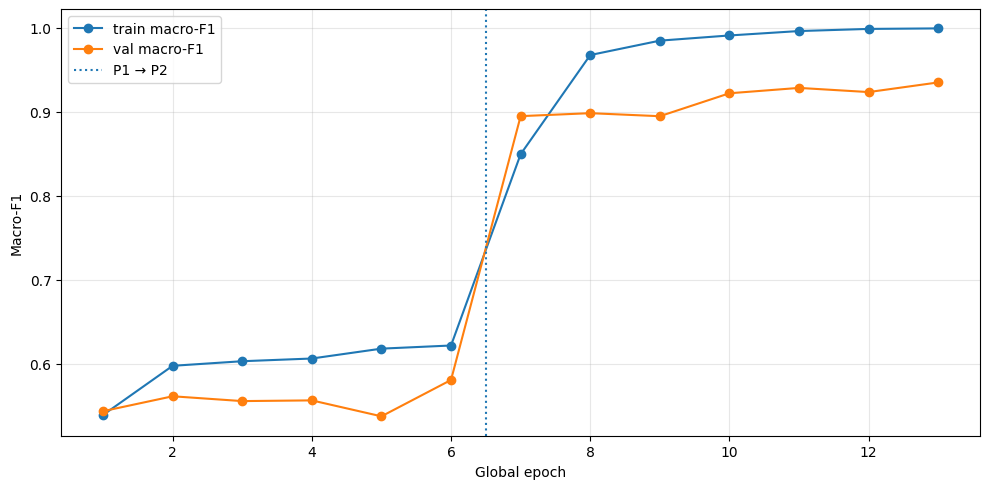

Loaded best checkpoint: val_f1=0.9350408167452032
VAL: loss=0.1566, acc=0.9594, macro-F1=0.9350

Classification report:
                     precision    recall  f1-score   support

 Lateral_lying_left       0.96      0.92      0.94       614
Lateral_lying_right       0.96      0.93      0.95       683
            Sitting       0.88      0.84      0.86       119
           Standing       0.99      0.99      0.99      1991
      Sternal_lying       0.93      0.95      0.94      1277

           accuracy                           0.96      4684
          macro avg       0.94      0.93      0.94      4684
       weighted avg       0.96      0.96      0.96      4684


Confusion matrix:
[[ 565    8    2    3   36]
 [   4  637    0    3   39]
 [   0    0  100    7   12]
 [   1    0    1 1978   11]
 [  19   18   10   16 1214]]


In [17]:
# ── Krzywe treningowe i raport walidacyjny ───────────────────────────────────
if len(history) > 0:
    hist_df = pd.DataFrame(history)
    display(hist_df.tail())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hist_df['global_epoch'], hist_df['train_f1'], marker='o', label='train macro-F1')
    ax.plot(hist_df['global_epoch'], hist_df['val_f1'], marker='o', label='val macro-F1')
    ax.axvline(EPOCHS_P1 + 0.5, linestyle=':', label='P1 → P2')
    ax.set_xlabel('Global epoch')
    ax.set_ylabel('Macro-F1')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'eva_large_training_f1.png', dpi=140, bbox_inches='tight')
    plt.show()

# Wczytaj best model i pokaż szczegółowy raport walidacji.
if CKPT_BEST.exists():
    ckpt = torch.load(CKPT_BEST, map_location='cpu')
    bare(model).load_state_dict(ckpt['model_state_dict'], strict=True)
    print(f'Loaded best checkpoint: val_f1={ckpt.get("best_val_f1", None)}')
else:
    print('No best checkpoint found; using current weights.')

val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)
print(f'VAL: loss={val_loss:.4f}, acc={val_acc:.4f}, macro-F1={val_f1:.4f}')
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)], zero_division=0))
print('\nConfusion matrix:')
print(confusion_matrix(y_true, y_pred))


In [18]:
# ── Inferencja z TTA i submission.csv ─────────────────────────────────────────
@torch.no_grad()
def predict_proba_for_tta_mode(model, df, tta_mode):
    ds = PigEvalDataset(df, VAL_TRANSFORM, return_label=False, tta_mode=tta_mode)
    loader = make_eval_loader(ds, batch_size=EVAL_BATCH_SIZE)
    model.eval()

    all_row_ids = []
    all_probs = []
    for step, (images, row_ids) in enumerate(loader, start=1):
        images = images.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(USE_AMP and DEVICE.type == 'cuda')):
            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu()

        if tta_mode == 'hflip':
            # Po horizontal flip model widzi lewą/leżącą jako prawą i odwrotnie,
            # więc odwracamy prawdopodobieństwa klas 0/1 z powrotem do oryginalnego układu.
            probs = probs[:, PROB_FLIP_INDEX]

        all_row_ids.extend(list(row_ids))
        all_probs.append(probs)

        if step == 1 or step % 25 == 0 or step == len(loader):
            bar_len = 30
            filled = int(bar_len * step / len(loader))
            bar = '█' * filled + '░' * (bar_len - filled)
            print(f'\r  {tta_mode:5s} |{bar}| {step:>4}/{len(loader):<4}', end='', flush=True)
    print()
    return all_row_ids, torch.cat(all_probs, dim=0).numpy()

# Wczytaj najlepszy checkpoint do inferencji.
if CKPT_BEST.exists():
    ckpt = torch.load(CKPT_BEST, map_location='cpu')
    bare(model).load_state_dict(ckpt['model_state_dict'], strict=True)
    print(f'Inference checkpoint: best val_f1={ckpt.get("best_val_f1", None)}')
elif CKPT_PHASE2.exists():
    ckpt = torch.load(CKPT_PHASE2, map_location='cpu')
    bare(model).load_state_dict(ckpt['model_state_dict'], strict=True)
    print('Inference checkpoint: phase2 final')
else:
    print('Inference checkpoint: current model weights')

row_ids_orig, probs_orig = predict_proba_for_tta_mode(model, test, 'orig')
row_ids_flip, probs_flip = predict_proba_for_tta_mode(model, test, 'hflip')
assert row_ids_orig == row_ids_flip, 'Row order mismatch between TTA modes!'

probs = (probs_orig + probs_flip) / 2.0
preds = probs.argmax(axis=1).astype(int)

submission = pd.DataFrame({'row_id': row_ids_orig, 'class_id': preds})
sample_sub = pd.read_csv(BASE_DIR / 'sample_submission.csv')

assert set(submission['row_id']) == set(sample_sub['row_id']), 'Niezgodne row_id z sample_submission!'
assert submission['class_id'].between(0, NUM_CLASSES - 1).all(), 'class_id poza zakresem!'

submission = submission.set_index('row_id').reindex(sample_sub['row_id']).reset_index()
submission.to_csv(SUBMISSION_PATH, index=False)

print('\nPrediction distribution:')
for cid, cnt in sorted(submission['class_id'].value_counts().items()):
    print(f'  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:>6,} ({100*cnt/len(submission):5.1f}%)')

print(f'\nSaved submission -> {SUBMISSION_PATH}')
display(submission.head())


Inference checkpoint: best val_f1=0.9350408167452032
  orig  |██████████████████████████████|  366/366 
  hflip |██████████████████████████████|  366/366 

Prediction distribution:
  [0] Lateral_lying_left       :    912 (  7.8%)
  [1] Lateral_lying_right      :  1,188 ( 10.1%)
  [2] Sitting                  :    242 (  2.1%)
  [3] Standing                 :  6,748 ( 57.6%)
  [4] Sternal_lying            :  2,618 ( 22.4%)

Saved submission -> /kaggle/working/submission_eva_large_tta.csv


,row_id,class_id
0,test_pen1_tur_cam1_20250920_174649_0000,3
1,test_pen1_tur_cam1_20250920_174649_0001,1
2,test_pen1_tur_cam1_20250920_174649_0002,1
3,test_pen1_tur_cam1_20250920_174649_0003,1
4,test_pen1_tur_cam1_20250920_174649_0004,0


In [19]:
# ── Lista plików wyjściowych ──────────────────────────────────────────────────
print('Output files:')
for p in sorted(OUT_DIR.glob('eva_large*')) + [SUBMISSION_PATH]:
    if p.exists():
        print(f'  {p.name:35s} {p.stat().st_size / (1024**2):8.1f} MB')


Output files:
  eva_large_best_checkpoint.pt          1157.0 MB
  eva_large_history.csv                    0.0 MB
  eva_large_last_checkpoint.pt          1157.0 MB
  eva_large_phase1_final.pt             1157.0 MB
  eva_large_phase2_final.pt             1157.0 MB
  eva_large_training_f1.png                0.1 MB
  submission_eva_large_tta.csv             0.5 MB
